In [53]:

!python --version

Python 3.9.6


In [54]:
import importlib

import datamanip
from train_eval.evaluate import evaluate_ensamble, evaluate
import utils
importlib.reload(utils)
from utils import load_best_model_based_on_match


import torch
from torch_geometric.loader import DataLoader
from filepath import *
from datamanip.datasetmanip.three_five_dataset import ThreeFiveDataset
from datamanip.plots import generate_matrix, visualize_samples_outside_of_radii

In [55]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [56]:
train_set = ThreeFiveDataset(root=dataset_path, match='ensemble', test_train_val="train")
test_set = ThreeFiveDataset(root=dataset_path, match='ensemble', test_train_val="test")
val_set = ThreeFiveDataset(root=dataset_path, match='ensemble', test_train_val="val")
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=True)

In [57]:

matches = ["1-1", "2-1", "2-2", "3-1", "3-2", "3-3", "3-4"]
ensemble = {}
for match in matches:
    ensemble[match] = load_best_model_based_on_match(match)

Using GAT_LN_HEAD for match 1-1
Using GAT_LN_HEAD for match 2-1
Using GAT_LN_HEAD for match 2-2
Using GAT for match 3-1
Using GAT_LN_HEAD for match 3-2
Using GAT_LN_HEAD for match 3-3
Using GAT_LN_HEAD for match 3-4


In [58]:

for match, model in ensemble.items():
    model.eval()

In [59]:

# Function to collect predictions from base models
def get_meta_features(loader):
    meta_features, labels = [], []
    for data in loader:
        outputs = []
        for match, model in ensemble.items():
            with torch.no_grad():

                prob = torch.sigmoid(model(data)).cpu().numpy()
                outputs.append(prob)
       #         print(prob)
        meta_features.append(np.hstack(outputs))
        labels.append(data.y.cpu().numpy())
        #print(labels)
    return np.vstack(meta_features), np.hstack(labels)

In [60]:
'''
def get_meta_features(loader):
    meta_features = []
    true_labels = []
    for data in loader:
        batch_size = data.num_graphs
        batch_features = [[] for _ in range(batch_size)]
        for model in ensemble.values():
            with torch.no_grad():
                output = model(data)
                probs = torch.sigmoid(output).squeeze().cpu().numpy()
                if probs.ndim == 0:
                    probs = np.expand_dims(probs, axis=0)
                preds = (probs >= 0.5).astype(int)
                confidences = np.abs(probs - 0.5)
                for i in range(batch_size):
                    batch_features[i].append([probs[i], preds[i], confidences[i]])
        meta_features.extend(batch_features)
        true_labels.extend(data.y.cpu().numpy())
    return np.array(meta_features), np.array(true_labels)
'''

'\ndef get_meta_features(loader):\n    meta_features = []\n    true_labels = []\n    for data in loader:\n        batch_size = data.num_graphs\n        batch_features = [[] for _ in range(batch_size)]\n        for model in ensemble.values():\n            with torch.no_grad():\n                output = model(data)\n                probs = torch.sigmoid(output).squeeze().cpu().numpy()\n                if probs.ndim == 0:\n                    probs = np.expand_dims(probs, axis=0)\n                preds = (probs >= 0.5).astype(int)\n                confidences = np.abs(probs - 0.5)\n                for i in range(batch_size):\n                    batch_features[i].append([probs[i], preds[i], confidences[i]])\n        meta_features.extend(batch_features)\n        true_labels.extend(data.y.cpu().numpy())\n    return np.array(meta_features), np.array(true_labels)\n'

In [61]:
meta_X_train, meta_y_train = get_meta_features(train_loader)

Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward


In [62]:
'''
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Define and train the meta-learner
meta_learner = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

meta_learner.fit(meta_X_train, meta_y_train)
'''

"\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.preprocessing import StandardScaler\n# Define and train the meta-learner\nmeta_learner = Pipeline([\n    ('scaler', StandardScaler()),\n    ('clf', LogisticRegression(max_iter=1000))\n])\n\nmeta_learner.fit(meta_X_train, meta_y_train)\n"

In [63]:

from sklearn.ensemble import RandomForestClassifier

In [64]:
meta_learner = RandomForestClassifier(n_estimators=100, random_state=42)
meta_learner.fit(meta_X_train, meta_y_train)


RandomForestClassifier(random_state=42)

In [65]:
meta_X_test, meta_y_test = get_meta_features(test_loader)

Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward
Forward


In [66]:
test_preds = meta_learner.predict(meta_X_test)

In [67]:
accuracy = accuracy_score(meta_y_test, test_preds)
print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.9510509645839332


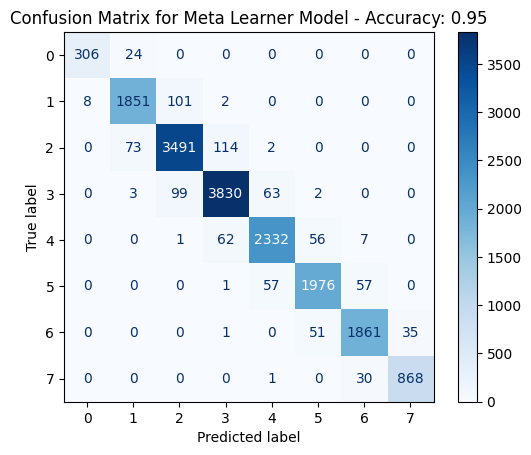

In [68]:
generate_matrix(meta_y_test, test_preds, accuracy, "Meta Learner Model")

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Define parameter grid
param_grid = {'n_estimators': [50, 100, 200, 300, 500]}

# Define the classifier
rf = RandomForestClassifier(random_state=42)

# Perform grid search
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(meta_X_train, meta_y_train)

# Best hyperparameter and best model
best_n_estimators = grid_search.best_params_['n_estimators']
best_rf_model = grid_search.best_estimator_

print(f"Best n_estimators: {best_n_estimators}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Evaluate the best model on the test set
y_pred = best_rf_model.predict(meta_X_test)
test_accuracy = accuracy_score(meta_y_test, y_pred)

print(f"Test set accuracy: {test_accuracy:.4f}")


In [ ]:
generate_matrix(meta_y_test, y_pred, accuracy, "Ensemble Model")

In [ ]:
outside_1 = np.sum(np.abs(np.array(meta_y_test) - np.array(y_pred)) > 1) / len(meta_y_test)
outside_2 = np.sum(np.abs(np.array(meta_y_test) - np.array(y_pred)) > 2) / len(meta_y_test)

In [ ]:

visualize_samples_outside_of_radii(accuracy, outside_1, outside_2)

In [ ]:

from sklearn.model_selection import GridSearchCV, validation_curve

train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=42),
    meta_X_train, meta_y_train,
    param_name="n_estimators",
    param_range=n_estimators_range,
    cv=5, scoring="accuracy", n_jobs=-1
)

# Compute mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot the validation curve
plt.figure(figsize=(8, 6))
plt.plot(n_estimators_range, train_mean, label="Training Score", color="blue", marker='o')
plt.fill_between(n_estimators_range, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.2)

plt.plot(n_estimators_range, val_mean, label="Validation Score", color="red", marker='o')
plt.fill_between(n_estimators_range, val_mean - val_std, val_mean + val_std, color="red", alpha=0.2)

plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Validation Curve for Random Forest")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
meta_learner = RandomForestClassifier(n_estimators=100, random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV with a 5-fold cross-validation
grid_search = GridSearchCV(estimator=meta_learner, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the training data
grid_search.fit(meta_X_train, meta_y_train)

# Print the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

In [ ]:
best_rf = grid_search.best_estimator_


meta_X_test, meta_y_test = get_meta_features(test_loader)
# Use it to make predictions on the test set
y_pred = best_rf.predict(meta_X_test)
test_accuracy = accuracy_score(meta_y_test, y_pred)

print(f"Test set accuracy: {test_accuracy:.4f}")
